# Supermarket Sales Analysis using KNN
Here we will analyze the `supermarket_sales.csv` dataset and build a K-Nearest Neighbors (KNN) model.
We will use `Unit price` and `Tax 5%` to predict `gross income`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Load the dataset
df = pd.read_csv("supermarket_sales.csv")
print("Dataset loaded successfully. Shape:", df.shape)
df.head()

Dataset loaded successfully. Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,state
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,"917 1st St, Dallas, TX 75001"
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,"82 Chestnut St, Boston, MA 02215"
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,"Spruce St, Los Angeles, CA 90001"
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,"Spruce St, Los Angeles, CA 90001"
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,"333 8th St, Los Angeles, CA 90001"


## Data Visualization
Let's visualize the relationships between our features (`Unit price`, `Tax 5%`) and the target variable (`gross income`).

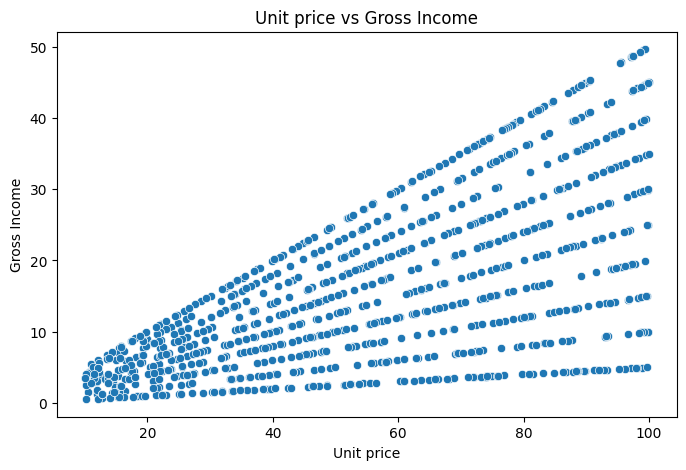

In [2]:
# Scatter plot: Unit price vs Gross Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Unit price"], y=df["gross income"])
plt.title("Unit price vs Gross Income")
plt.xlabel("Unit price")
plt.ylabel("Gross Income")
plt.show()

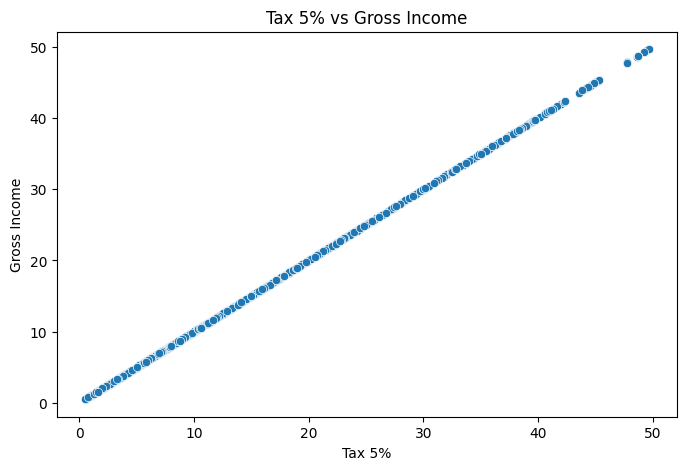

In [3]:
# Scatter plot: Tax 5% vs Gross Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Tax 5%"], y=df["gross income"])
plt.title("Tax 5% vs Gross Income")
plt.xlabel("Tax 5%")
plt.ylabel("Gross Income")
plt.show()

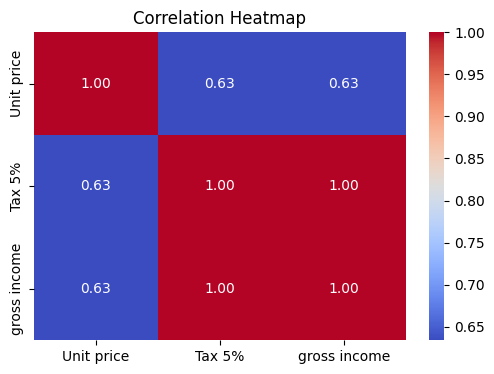

In [4]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
correlation_matrix = df[["Unit price", "Tax 5%", "gross income"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
# Select features (X) and target (y)
X = df[["Unit price", "Tax 5%"]]
y = df["gross income"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (Very important for KNN algorithm)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data separated and scaled successfully.")

Data separated and scaled successfully.


In [6]:
# Initialize and train the KNN Regressor model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 0.0898
R-squared (R2 Score): 0.9994


In [7]:
# Save the trained model and the scaler for future use
joblib.dump(knn, "knn_model.pkl")
joblib.dump(scaler, "knn_scaler.pkl")

print("KNN model and scaler saved successfully!")

KNN model and scaler saved successfully!
